# **Deep Learning -Anomaly Detection with U-Net Autoencoder- Spring 2025**

CELL 1 — CONFIG, IMPORTS, GLOBAL SEED, NAMED CONSTANTS, Deterministic setup

In [1]:
# Deterministic setup
import os
import random
# Fix Python hash seed
os.environ['PYTHONHASHSEED'] = str(42)
# Make cuBLAS deterministic (CUDA >= 10.2 / relevant versions)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ":4096:8"   # or ":16:8" on some systems

import numpy as np
import torch

# Global seed value (
SEED = 42

# Seed Python, numpy, torch (CPU)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# If CUDA available, seed all GPU RNGs
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# PyTorch deterministic settings (this will error if PyTorch can’t make an op deterministic)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# For newer PyTorch versions additionally enable:
# (this will raise an error if a nondeterministic op is used )
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    # older PyTorch: torch.set_deterministic(True) or not available
    pass

# CONFIG (this part change settings for quick vs final runs)
from pathlib import Path
import json, random, os, math

# DATASET CONFIG
DATASET_CATEGORY = 'hazelnut'   


QUICK_RUN = True

if QUICK_RUN:
    IMAGE_SIZE = 128
    BATCH_SIZE = 8
    EPOCHS = 3
    LR = 1e-3
else:
    IMAGE_SIZE = 256
    BATCH_SIZE = 12   # adjust down if hit OOM
    EPOCHS = 30
    LR = 1e-3

WORK_DIR = Path('/kaggle/working/mvtec_hazelnut_resnet_unet_mse_only')
WORK_DIR.mkdir(parents=True, exist_ok=True)

# REPRODUCIBILITY
GLOBAL_SEED = 42

# MODEL / TRAINING OPTIONS
WEIGHT_DECAY = 1e-5          # small weight decay
CLIP_GRAD_NORM = 2.0         # gradient clipping
EARLY_STOPPING_PATIENCE = 7  # patience for val loss

# Misc
NUM_WORKERS = 0

# IMPORTS
import numpy as np
import torch, torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms
from torchvision.transforms.functional import InterpolationMode
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, roc_curve, auc
import time, tqdm

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# SET GLOBAL SEED (reproducibility) 
def set_seed(seed=GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(GLOBAL_SEED)

# Save config for record
cfg = dict(DATASET_CATEGORY=DATASET_CATEGORY, QUICK_RUN=QUICK_RUN, IMAGE_SIZE=IMAGE_SIZE,
           BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS, LR=LR, GLOBAL_SEED=GLOBAL_SEED,
           WEIGHT_DECAY=WEIGHT_DECAY, WORK_DIR=str(WORK_DIR))

with open(WORK_DIR / 'config.json','w') as f:
    json.dump(cfg, f, indent=2)

print("Config saved to", WORK_DIR / 'config.json')

Device: cuda
Config saved to /kaggle/working/mvtec_hazelnut_resnet_unet_mse_only/config.json


CELL 2 — LOCATE DATA & DATASET CLASS

In [2]:
# Auto-detect dataset under /kaggle/input
KAGGLE_INPUT = Path('/kaggle/input')

def find_dataset_root(category='hazelnut'):
    for p in KAGGLE_INPUT.iterdir():
        if p.is_dir():
            for sub in p.rglob('*'):
                if sub.is_dir() and sub.name.lower() == category.lower():
                    return sub.parent
    return None

DATA_ROOT = find_dataset_root(DATASET_CATEGORY)
if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the MVTec dataset under /kaggle/input. Please add the dataset in the right-side 'Add data' panel."
    )

print("Using DATA_ROOT =", DATA_ROOT)
category_root = Path(DATA_ROOT) / DATASET_CATEGORY
print("Category root:", category_root)

def list_images(folder):
    folder = Path(folder)
    return sorted([p for p in folder.glob('*') if p.suffix.lower() in ('.png','.jpg','.jpeg')])

class MVTecHazelnutDataset(Dataset):
    def __init__(self, root:Path, mode='train', transform=None, img_list=None):
        """
        mode:
        'train'/'val' : uses root/train/good images (img_list optional to subset indices)
        """
        self.root = Path(root)
        self.mode = mode
        self.transform = transform
        self.img_paths = []
        self.mask_paths = []
        if mode in ('train','val'):
            base_list = list_images(self.root / 'train' / 'good')
            if img_list is not None:
                # img_list is list of indices or paths; accept list of indices
                if all(isinstance(x, int) for x in img_list):
                    self.img_paths = [base_list[i] for i in img_list]
                else:
                    # assume list of Paths
                    self.img_paths = [Path(x) for x in img_list]
            else:
                self.img_paths = base_list
            self.mask_paths = [None] * len(self.img_paths)
        elif mode == 'test':
            test_dir = self.root / 'test'
            imgs = []
            for sub in sorted(test_dir.iterdir()):
                if sub.is_dir():
                    imgs += list_images(sub)
            self.img_paths = sorted(imgs)
            # locate ground truth masks
            gt_root = self.root / 'ground_truth'
            mask_map = {}
            if gt_root.exists():
                for gsub in gt_root.iterdir():
                    if gsub.is_dir():
                        for mp in list_images(gsub):
                            k = mp.stem.replace('_mask','')
                            mask_map[k] = mp
            self.mask_paths = [ mask_map.get(p.stem, None) for p in self.img_paths ]
        else:
            raise ValueError("mode must be 'train','val', or 'test'")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        p = self.img_paths[idx]
        img = Image.open(p).convert('RGB')
        mask = None
        if self.mode == 'test' and self.mask_paths[idx] is not None:
            mask = Image.open(self.mask_paths[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
            if mask is not None:
                # use InterpolationMode.NEAREST for masks
                mask = transforms.functional.resize(mask, (img.shape[1], img.shape[2]), interpolation=InterpolationMode.NEAREST)
                mask = transforms.ToTensor()(mask).float()
            else:
                mask = torch.zeros((1, img.shape[1], img.shape[2]), dtype=torch.float32)
        return img, mask, str(self.img_paths[idx].name)

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

# Build datasets and deterministic split (no leakage).
# two dataset objects with identical ordering but different transforms created
full_train_with_train_transform = MVTecHazelnutDataset(category_root, mode='train', transform=train_transform)
full_train_with_test_transform = MVTecHazelnutDataset(category_root, mode='train', transform=test_transform)

n = len(full_train_with_train_transform)
val_count = max(1, int(0.1 * n))
train_count = n - val_count

# deterministic permutation using global seed
rng = torch.Generator()
rng.manual_seed(GLOBAL_SEED)
perm = torch.randperm(n, generator=rng).tolist()
train_idx = perm[:train_count]
val_idx = perm[train_count:]

# Create Subsets referencing the two dataset objects 
train_dataset = Subset(full_train_with_train_transform, train_idx)
val_dataset = Subset(full_train_with_test_transform, val_idx)

test_dataset = MVTecHazelnutDataset(category_root, mode='test', transform=test_transform)

# REPRODUCIBILITY

def seed_worker(worker_id):
    """
    Sets the seed for a DataLoader worker to ensure reproducible augmentations.
    """
    # Use the global seed and offset it by the worker ID
    worker_seed = GLOBAL_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)
    # There is no need to set CUDA seeds here as workers are for CPU data loading

# Create a generator for reproducible shuffling in the main process
g = torch.Generator()
g.manual_seed(GLOBAL_SEED)




from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=True,
    worker_init_fn=seed_worker,  
    generator=g                 
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=True,
    worker_init_fn=seed_worker  
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=1, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=True,
    worker_init_fn=seed_worker   
)

print(f"Total train/good images: {n}, Train images: {len(train_dataset)}, Val images: {len(val_dataset)}, Test images: {len(test_dataset)}")

Using DATA_ROOT = /kaggle/input/mvtec-ad
Category root: /kaggle/input/mvtec-ad/hazelnut
Total train/good images: 391, Train images: 352, Val images: 39, Test images: 110


CELL 3 — MODEL (U-NET DECODER WITH RESNET-50 ENCODER)

In [3]:
import torchvision.models as models

class ConvRelu(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self,x): return self.conv(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvRelu(in_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            diffY = skip.size()[2] - x.size()[2]
            diffX = skip.size()[3] - x.size()[3]
            x = F.pad(x, [diffX//2, diffX - diffX//2, diffY//2, diffY - diffY//2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

class Model(nn.Module):
    def __init__(self, pretrained_encoder=True):
        super().__init__()
        # ImageNet normalization constants 
        self.register_buffer('imagenet_mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('imagenet_std', torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

        # Create a ResNet-50 encoder skeleton (weights loaded in init())
        resnet = models.resnet50(pretrained=False)
        self.enc_conv1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # -> 64
        self.enc_pool = resnet.maxpool
        self.enc_layer1 = resnet.layer1  # -> 256
        self.enc_layer2 = resnet.layer2  # -> 512
        self.enc_layer3 = resnet.layer3  # -> 1024
        self.enc_layer4 = resnet.layer4  # -> 2048

        # Decoder
        self.up3 = Up(2048 + 1024, 1024)
        self.up2 = Up(1024 + 512, 512)
        self.up1 = Up(512 + 256, 256)
        self.up0 = Up(256 + 64, 128)

        # Add a final upsampling layer to match input size
        self.final_up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        

        self.final_conv = nn.Conv2d(128, 3, kernel_size=1)
        self.out_act = nn.Sigmoid()

        self._pretrained_requested = pretrained_encoder

    def init(self, pretrained=True):
        """
        Proper initialization:
        If pretrained=True, load torchvision ResNet-50 pretrained encoder weights
        """
        if pretrained:
            resnet_pre = models.resnet50(pretrained=True)
            # copy encoder blocks weights individually 
            # conv1 + bn1
            self.enc_conv1[0].load_state_dict(resnet_pre.conv1.state_dict())
            self.enc_conv1[1].load_state_dict(resnet_pre.bn1.state_dict())
            # layers
            self.enc_layer1.load_state_dict(resnet_pre.layer1.state_dict())
            self.enc_layer2.load_state_dict(resnet_pre.layer2.state_dict())
            self.enc_layer3.load_state_dict(resnet_pre.layer3.state_dict())
            self.enc_layer4.load_state_dict(resnet_pre.layer4.state_dict())
            print("Loaded ImageNet pretrained weights into encoder.")
        else:
            print("Initialized without pretrained encoder weights.")

        # Initialize decoder weights only 
        def init_decoder_weights(m):
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
        # apply to decoder modules explicitly
        for module in [self.up3, self.up2, self.up1, self.up0, self.final_conv]:
            module.apply(init_decoder_weights)
        print("Decoder weights initialized (encoder preserved).")

    def forward(self, x_raw):
        # x_raw in [0,1], shape [B,3,H,W]; normalize for encoder
        x = (x_raw - self.imagenet_mean) / self.imagenet_std
        x1 = self.enc_conv1(x)
        x_pool = self.enc_pool(x1)
        x2 = self.enc_layer1(x_pool)
        x3 = self.enc_layer2(x2)
        x4 = self.enc_layer3(x3)
        x5 = self.enc_layer4(x4)
        d3 = self.up3(x5, x4)
        d2 = self.up2(d3, x3)
        d1 = self.up1(d2, x2)
        d0 = self.up0(d1, x1)
        
        # Apply the final upsampling before the last convolution
        d_final = self.final_up(d0)
        out = self.final_conv(d_final)
       
        
        out = self.out_act(out)
        return out

# Instantiate model 
model = Model(pretrained_encoder=True)
print("Model created.")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model created.


CELL 4 — LOSS FUNCTION: PIXELWISE MSE

In [4]:
loss_function = nn.MSELoss()

CELL 5 — MODEL PREPARATION, OPTIMIZER & SCHEDULER

In [5]:
# Initialize model weights (load pretrained encoder) then move to device
model.init(pretrained=True)
model.to(device)

print("Training the entire model.")

# Setup optimizer to include all model parameters
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler: ReduceLROnPlateau to shrink LR on plateau of val loss (robust)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded ImageNet pretrained weights into encoder.
Decoder weights initialized (encoder preserved).
Training the entire model.


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


CELL 6 — TRAINING LOOP

Epoch 1  train_loss=0.0224  val_loss=0.0039
  Saved best model at epoch 1


Epoch 2  train_loss=0.0023  val_loss=0.0016
  Saved best model at epoch 2


Epoch 3  train_loss=0.0028  val_loss=0.0787
Training completed. Best val epoch: 2. Models saved to /kaggle/working/mvtec_hazelnut_resnet_unet_mse_only


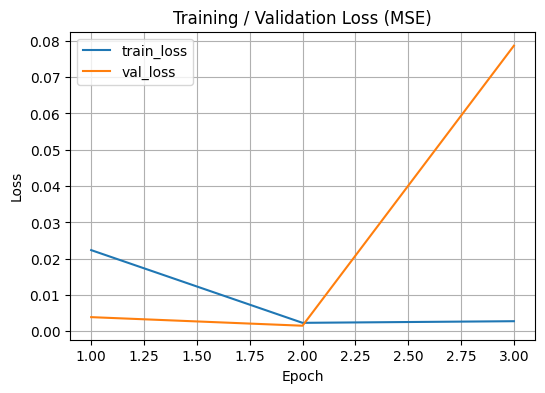

In [6]:
from torch.nn.utils import clip_grad_norm_

best_val_loss = float('inf')
best_epoch = -1
no_improve_epochs = 0

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    total = 0
    pbar = tqdm.tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} Train", leave=False)
    for imgs, masks, names in pbar:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        recon = model(imgs)
        
        # Using MSE loss
        loss = loss_function(recon, imgs)
        
        loss.backward()
        # gradient clipping
        if CLIP_GRAD_NORM is not None:
            clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM)
        optimizer.step()
        
        b = imgs.size(0)
        running_loss += loss.item() * b
        total += b
        pbar.set_postfix({'loss': f"{running_loss/total:.4f}"})
        
    train_loss = running_loss/total
    train_losses.append(train_loss)

    # validation
    model.eval()
    val_running_loss = 0.0
    val_total = 0
    with torch.no_grad():
        for imgs, masks, names in val_loader:
            imgs = imgs.to(device)
            recon = model(imgs)
            
            # Using simple MSE loss for validation as well
            loss = loss_function(recon, imgs)
            
            b = imgs.size(0)
            val_running_loss += loss.item() * b
            val_total += b
            
    val_loss = val_running_loss / val_total if val_total>0 else float('nan')
    val_losses.append(val_loss)
    
    # scheduler step (ReduceLROnPlateau uses val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")
    
    # checkpoint best val
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        no_improve_epochs = 0
        torch.save(model.state_dict(), WORK_DIR / 'model_best_val.pth')
        print(f"  Saved best model at epoch {epoch}")
    else:
        no_improve_epochs += 1

   
    # early stopping
    if no_improve_epochs >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping: no improvement for {no_improve_epochs} epochs.")
        break

# Save final model
torch.save(model.state_dict(), WORK_DIR / 'model_final.pth')

print(f"Training completed. Best val epoch: {best_epoch}. Models saved to {WORK_DIR}")

# Plot training curves
plt.figure(figsize=(6,4))
plt.plot(range(1, len(train_losses)+1), train_losses, label='train_loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.title('Training / Validation Loss (MSE)')
plt.savefig(WORK_DIR / 'loss_plot.png', bbox_inches='tight')
plt.show()

CELL 7 — EVALUATION ON VALIDATION

In [7]:
# Collect validation image-level scores (mean pixel abs error) using validation set (normal-only)
model.eval()
val_image_scores = []

with torch.no_grad():
    for imgs, masks, names in val_loader:
        imgs = imgs.to(device)
        recon = model(imgs)
        err = (imgs - recon).abs().mean(dim=1)  # [B,H,W]
        for b in range(err.shape[0]):
            val_image_scores.append(float(err[b].mean().cpu().numpy()))

import pandas as pd
pd.DataFrame({'val_image_score': val_image_scores}).to_csv(WORK_DIR / 'val_scores.csv', index=False)
print("Saved validation image scores to", WORK_DIR / 'val_scores.csv')
print("Val score mean/std:", np.mean(val_image_scores), np.std(val_image_scores))

Saved validation image scores to /kaggle/working/mvtec_hazelnut_resnet_unet_mse_only/val_scores.csv
Val score mean/std: 0.13814274245538774 0.17298260537533974


CELL 8 — FINAL TEST EVALUATION

In [8]:
# FINAL evaluation: load best validation model (winning model) and evaluate only on the test set.
best_model_path = WORK_DIR / 'model_best_val.pth'

if not best_model_path.exists():
    best_model_path = WORK_DIR / 'model_final.pth'

print("Loading model from:", best_model_path)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

all_image_scores = []
all_image_labels = []
all_pixel_scores = []
all_pixel_labels = []
results = []

with torch.no_grad():
    for img, mask, name in tqdm.tqdm(test_loader, desc="Test Inference"):
        img = img.to(device)
        recon = model(img)
        err_map = (img - recon).abs().mean(dim=1, keepdim=True)  # [1,1,H,W]
        err_np = err_map.squeeze().cpu().numpy()
        mask_np = mask.squeeze().cpu().numpy()
        img_mean = float(err_np.mean())
        img_p95 = float(np.percentile(err_np, 95))
        label = 1 if mask_np.sum() > 0 else 0
        all_image_scores.append(img_mean)
        all_image_labels.append(label)
        all_pixel_scores.append(err_np.flatten())
        all_pixel_labels.append((mask_np>0).astype(np.uint8).flatten())
        results.append({'name': name, 'img_mean': img_mean, 'img_p95': img_p95, 'label': label, 'err_map': err_np, 'mask': mask_np})

all_image_scores = np.array(all_image_scores)
all_image_labels = np.array(all_image_labels)
pixel_scores = np.concatenate(all_pixel_scores)
pixel_labels = np.concatenate(all_pixel_labels)

# Compute AUROCs
image_auroc = roc_auc_score(all_image_labels, all_image_scores) if len(set(all_image_labels))>1 else float('nan')
pixel_auroc = roc_auc_score(pixel_labels, pixel_scores) if len(set(pixel_labels))>1 else float('nan')

print(f"Image AUROC (MAE mean): {image_auroc:.4f}, Pixel AUROC: {pixel_auroc:.4f}")

# Threshold by 99th percentile of validation scores (normal-only)
val_scores = pd.read_csv(WORK_DIR / 'val_scores.csv')['val_image_score'].values
threshold = float(np.percentile(val_scores, 99))
print(f"Threshold (99th percentile of val normal image mean-error): {threshold:.6f}")

pred_labels = (all_image_scores > threshold).astype(int)
precision, recall, f1, _ = precision_recall_fscore_support(all_image_labels, pred_labels, average='binary', zero_division=0)
print(f"Image-level @ threshold: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

# Pixel-level thresholding using same numeric threshold applied to pixel scores
pixel_pred = (pixel_scores > threshold).astype(int)
p_precision, p_recall, p_f1, _ = precision_recall_fscore_support(pixel_labels, pixel_pred, average='binary', zero_division=0)
print(f"Pixel-level @ threshold: Precision={p_precision:.4f}, Recall={p_recall:.4f}, F1={p_f1:.4f}")

# Save per-image CSV
rows = []
for r in results:
    rows.append({'name': r['name'], 'img_mean': r['img_mean'], 'img_p95': r['img_p95'], 'label': r['label']})
df = pd.DataFrame(rows)
df['pred_label'] = (df['img_mean'] > threshold).astype(int)
df.to_csv(WORK_DIR / 'scores.csv', index=False)

# Save metrics
metrics = {
    'image_auroc_mae': float(image_auroc),
    'pixel_auroc': float(pixel_auroc),
    'threshold_val_99perc': threshold,
    'image_precision_at_threshold': float(precision),
    'image_recall_at_threshold': float(recall),
    'image_f1_at_threshold': float(f1),
    'pixel_precision_at_threshold': float(p_precision),
    'pixel_recall_at_threshold': float(p_recall),
    'pixel_f1_at_threshold': float(p_f1),
}
with open(WORK_DIR / 'metrics.json','w') as f:
    json.dump(metrics, f, indent=2)

print("Saved scores.csv and metrics.json to", WORK_DIR)
print(json.dumps(metrics, indent=2))

Loading model from: /kaggle/working/mvtec_hazelnut_resnet_unet_mse_only/model_best_val.pth


Test Inference: 100%|██████████| 110/110 [00:07<00:00, 13.80it/s]


Image AUROC (MAE mean): 0.7407, Pixel AUROC: 0.4721
Threshold (99th percentile of val normal image mean-error): 0.534023
Image-level @ threshold: Precision=0.0000, Recall=0.0000, F1=0.0000
Pixel-level @ threshold: Precision=0.0000, Recall=0.0000, F1=0.0000
Saved scores.csv and metrics.json to /kaggle/working/mvtec_hazelnut_resnet_unet_mse_only
{
  "image_auroc_mae": 0.740702479338843,
  "pixel_auroc": 0.4721280942511912,
  "threshold_val_99perc": 0.5340228629112244,
  "image_precision_at_threshold": 0.0,
  "image_recall_at_threshold": 0.0,
  "image_f1_at_threshold": 0.0,
  "pixel_precision_at_threshold": 0.0,
  "pixel_recall_at_threshold": 0.0,
  "pixel_f1_at_threshold": 0.0
}


CELL 9 — VISUALIZE EXAMPLES

Displaying 6 example visualizations:


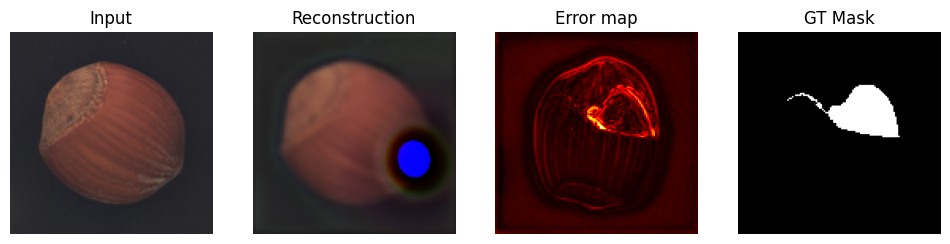

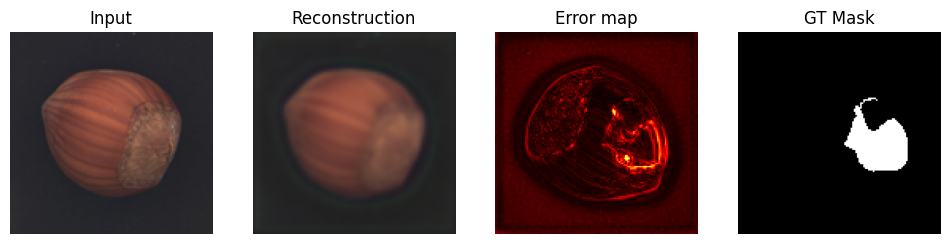

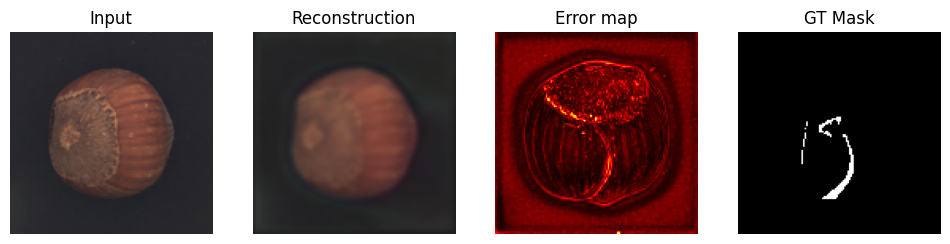

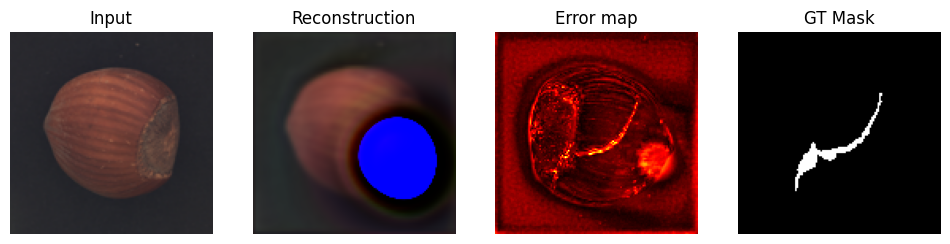

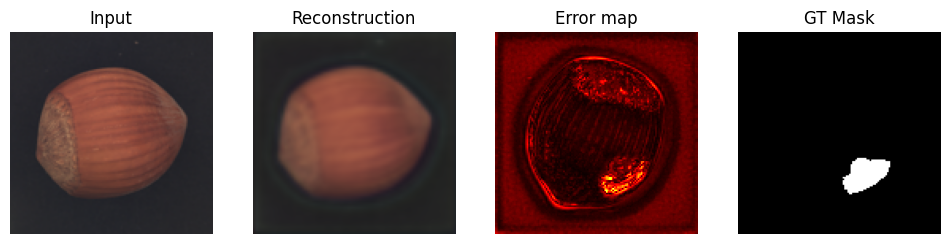

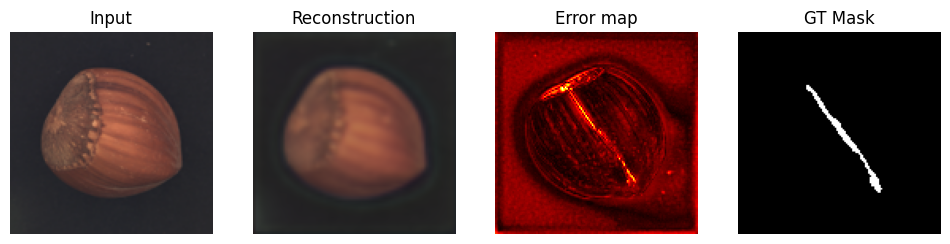

In [9]:
# Show N example visualizations of Input / Reconstruction / Error map / Mask
def show_example_plots(idx, results):
    r = results[idx]
    err = r['err_map']
    mask = r['mask']
    # Try to find the input image on disk

    img_path = None
    for sub in (category_root / 'test').iterdir():
        p = sub / r['name'][0]
        if p.exists():
            img_path = p
            break
    if img_path:
        img = Image.open(img_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
        inp = np.array(img).astype(np.float32)/255.0
    else:
        inp = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3))
    
    # produce reconstruction
    img_t = test_transform(Image.fromarray((inp*255).astype(np.uint8))).unsqueeze(0).to(device)
    with torch.no_grad():
        recon = model(img_t).cpu().squeeze().permute(1,2,0).numpy()
        
    plt.figure(figsize=(12,4))
    plt.subplot(1,4,1); plt.imshow(inp); plt.title('Input'); plt.axis('off')
    plt.subplot(1,4,2); plt.imshow(np.clip(recon,0,1)); plt.title('Reconstruction'); plt.axis('off')
    plt.subplot(1,4,3); plt.imshow(err, cmap='hot'); plt.title('Error map'); plt.axis('off')
    plt.subplot(1,4,4); plt.imshow(mask.squeeze(), cmap='gray'); plt.title('GT Mask'); plt.axis('off')
    
  
    plt.show()
    

N = min(6, len(results))
print(f"Displaying {N} example visualizations:")
for i in range(N):
    show_example_plots(i, results)